In [1]:
# ── Mount Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, os

# ── Point Python at your project files ───────────────────────
PROJECT = '/content/drive/MyDrive/waf-ml-project/ml'
sys.path.insert(0, PROJECT)           # so   import feature_engineering   works
os.chdir(PROJECT)                     # so   Path("../data/...")   resolves
print(f"Working dir: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/waf-ml-project/ml


In [2]:
 %%capture
 !pip install -r /content/drive/MyDrive/waf-ml-project/ml/requirements_train.txt # run once

In [3]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy onnxscript

# Notebook 03 — Layer 2A Experiments
Train Isolation Forest and Shallow Autoencoder. Compare on FPR / TPR / AUC. Export winner to ONNX.

In [4]:
#!cat layer2a/candidates/autoencoder_shallow.py



In [5]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import mlflow
from pathlib import Path

from feature_engineering.normalizer import Normalizer
from layer2a.candidates.isolation_forest import IsolationForestModel
from ml.layer2a.candidates.autoencoder_shallow import ShallowAutoencoderModel
from layer2a.evaluate import evaluate_candidate, pick_best, threshold_sweep
from evaluation.compare_models import compare_l2a, pick_best_l2a
from evaluation.benchmark import benchmark_isolation_forest, benchmark_autoencoder

SPLITS  = Path("../data/splits")
EXPORTS = Path("../exported_models")
EXPORTS.mkdir(exist_ok=True)

## 1. Load splits

In [6]:
X_n_train = np.load(SPLITS / "l2a_normal_train.npy")
X_n_val   = np.load(SPLITS / "l2a_normal_val.npy")
X_test    = np.load(SPLITS / "l2a_test_X.npy")
y_test    = np.load(SPLITS / "l2a_test_y.npy")

norm = Normalizer.load(str(EXPORTS / "scaler_l2a.pkl"))
X_train = norm.transform(X_n_train)
X_val   = norm.transform(X_n_val)
X_te    = norm.transform(X_test)

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_te.shape}")
print(f"Test attack rate: {y_test.mean():.2%}")

[Normalizer] Loaded from ../exported_models/scaler_l2a.pkl
Train: (25200, 25)  Val: (5400, 25)  Test: (68124, 25)
Test attack rate: 92.07%


## 2. Candidate 1 — Isolation Forest

In [7]:
mlflow.set_experiment("layer2a")
iforest = IsolationForestModel()
iforest.train(X_train)
iforest.tune_threshold(X_val, y_val=None, target_fpr=0.05)
res_iforest = evaluate_candidate(iforest, X_te, y_test, name="isolation_forest")
print(res_iforest)

2026/03/30 05:06:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 05:06:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[IForest] Trained on 25200 normal samples.
[IForest] Threshold (95th pct, unsupervised): 0.00259

[evaluate] isolation_forest
  auc                   : 0.8722
  avg_precision         : 0.9816
  fpr                   : 0.0485
  tpr                   : 0.1984
  tp                    : 12447
  fp                    : 262
  tn                    : 5138
  fn                    : 50277
{'model': 'isolation_forest', 'auc': 0.8722, 'avg_precision': 0.9816, 'fpr': 0.0485, 'tpr': 0.1984, 'tp': 12447, 'fp': 262, 'tn': 5138, 'fn': 50277}


## 3. Candidate 2 — Shallow Autoencoder

In [8]:
from sklearn.metrics import roc_auc_score, confusion_matrix, average_precision_score
# 1. Initialize the Wrapper Class (not the raw PyTorch Module)
ae = ShallowAutoencoderModel()

# 2. Call the .train() method from the wrapper
# Note: Code 1 expects Normalized data.
# Ensure X_train and X_val have been through norm.transform()
ae.train(X_train, X_val, run_name="l2a_autoencoder_v1")

# 3. Use the wrapper's .predict() and .anomaly_scores() for evaluation
# We create a results dict to match your compare_candidates format
from sklearn.metrics import roc_auc_score, confusion_matrix

scores = ae.anomaly_scores(X_te)
preds = ae.predict(X_te)

# Calculate metrics
tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
auc = roc_auc_score(y_test, scores)
avg_p = average_precision_score(y_test, scores)

res_ae = {
    "model": "shallow_autoencoder",
    "auc": round(auc, 4),
    "avg_precision": round(avg_p, 4),
    "fpr": round(fp / (fp + tn), 4),
    "tpr": round(tp / (tp + fn), 4),
    "tp": tp, "fp": fp, "tn": tn, "fn": fn
}

print(res_ae)

[AE] Training on cpu
  epoch  10 | train=0.06129 | val=0.39034
[AE] Early stopping at epoch 10
[AE] Threshold = 1.604902  (mean=0.04491 + 2.5*std=0.62400)
{'model': 'shallow_autoencoder', 'auc': np.float64(0.9335), 'avg_precision': np.float64(0.994), 'fpr': np.float64(0.0002), 'tpr': np.float64(0.688), 'tp': np.int64(43157), 'fp': np.int64(1), 'tn': np.int64(5399), 'fn': np.int64(19567)}


## 4. Compare candidates

In [9]:
all_results = [res_iforest, res_ae]
df_compare = compare_l2a(all_results)
df_compare


=== Layer 2A Model Comparison ===
              Model    AUC  Avg Precision  TPR (recall)    FPR    TP  FP   TN    FN
shallow_autoencoder 0.9335         0.9940        0.6880 0.0002 43157   1 5399 19567
   isolation_forest 0.8722         0.9816        0.1984 0.0485 12447 262 5138 50277


,Model,AUC,Avg Precision,TPR (recall),FPR,TP,FP,TN,FN
1,shallow_autoencoder,0.9335,0.9940,0.6880,0.0002,43157,1,5399,19567
0,isolation_forest,0.8722,0.9816,0.1984,0.0485,12447,262,5138,50277


## 5. Pick winner and export ONNX

In [10]:
winner_name, winner_model = pick_best_l2a(
    all_results,
    models={"isolation_forest": iforest, "shallow_autoencoder": ae},
    max_fpr=0.05,
)
print(f"Winner: {winner_name}")

onnx_path = str(EXPORTS / "layer2a_best.onnx")
winner_model.export_onnx(onnx_path)


[compare] L2A Winner: shallow_autoencoder  FPR=0.0002  TPR=0.688  AUC=0.9335
Winner: shallow_autoencoder


/content/drive/MyDrive/waf-ml-project/ml/layer2a/candidates/autoencoder_shallow.py:216: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0330 05:07:02.659000 12774 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ShallowAE([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ShallowAE([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 5 of general pattern rewrite rules.
[AE] ONNX exported → ../exported_models/layer2a_best.onnx
[AE] Avg inference: 0.038ms  |  PASS


## 6. Latency benchmark

In [11]:
if winner_name == "isolation_forest":
    lat = benchmark_isolation_forest(onnx_path)
else:
    lat = benchmark_autoencoder(onnx_path)

print(f"Mean: {lat['mean_ms']}ms  P99: {lat['p99_ms']}ms  Pass: {lat['pass']}")

Mean: 0.025ms  P99: 0.053ms  Pass: True


## 7. ROC curve

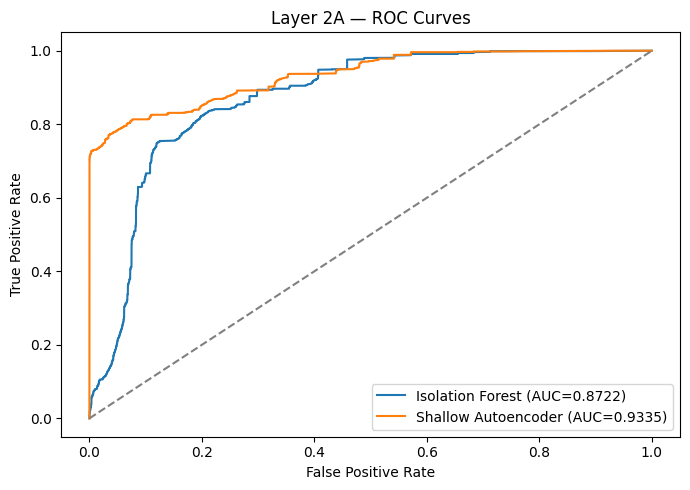

Winner exported to: ../exported_models/layer2a_best.onnx


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 5))
for name, model, result in [
    ("Isolation Forest", iforest, res_iforest),
    ("Shallow Autoencoder", ae, res_ae),
]:
    scores   = model.anomaly_scores(X_te)
    fpr, tpr, _ = roc_curve(y_test, scores)
    ax.plot(fpr, tpr, label=f"{name} (AUC={result['auc']})")

ax.plot([0,1],[0,1],"--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Layer 2A — ROC Curves")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/03_l2a_roc.png", dpi=120)
plt.show()
print(f"Winner exported to: {onnx_path}")